# Screen contacts for noise and responsivity to images
Specifically designed for EmotionTask data <br>

Meant as a way to determine which contacts should be analyzed

**Prerequisites:** <br>
Files <br>
* *montage.csv
* *iEEG.csv
* *events.csv
<br>

Code <br>
* numpy
* pandas
* matplotlib
* seaborn ... (maybe)
* scipy
* ipywidgets
* my GRID_lab_python repo (https://github.com/jtmiles/GRID_lab_python)


Contacts drawn from a montage file <br>
*All* pairs of valid contacts from the montage file are identified <br>
Bipolar rereferenced signals are processed and screened for noise <br>
ERPs are generated to compare across contacts/regions

### Imports

In [1]:
# imports
import numpy as np
# import numpy.ma as ma
import pandas as pd
import os
import re
# from itertools import combinations
# from datetime import datetime, date, time, timedelta
import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# import seaborn as sns

from scipy.signal import find_peaks

from iEEG_utils.loading import read_data
from iEEG_utils.processing import filtering
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils

# import ipywidgets as widgets

# instantiate a random number generator
rng = np.random.default_rng()

### notebook specific functions

In [2]:
# hm. do I want to add ERP stuff here? Or just use this for data checks?
# probably just data checks

def plot_ERPs(ERP_mat,imgs,ERP_thresh,plot_ts,ixA,ixB):
    '''
    plot average ERP for each image category
    specify categories (array of strings)
    set threshold for SNR calculation
    use ixA and ixB as integer ixs for finding max/min
    '''

    if "house" in imgs.to_numpy():
        ERP_mat = ERP_mat[imgs!="house",:]
        imgs = imgs[imgs!="house"]
        
    img_cats = imgs.unique()
    img_cats.sort()
    
    fig,ax = plt.subplots(2,len(img_cats),tight_layout=True,figsize=(12,6),
                         sharex=True)
    cmap = plt.cm.grey
    vmin = np.percentile(ERP_mat.flatten(),2.5)
    vmax = np.percentile(ERP_mat.flatten(),97.5)
    xticks = np.linspace(min(plot_ts),max(plot_ts),7)
    yticks = np.round(ax[0,0].get_yticks(),decimals=2)
    pline = np.ones((len(plot_ts),))

    # make a dict of amplitudes and array of avg ERPs
    ERP_amps = {}
    ERPs = np.zeros([len(img_cats),len(plot_ts)])
    # iterate through image categories and plot
    for ix,cat in enumerate(img_cats):
        catmat = ERP_mat[imgs==cat,:]
        ERP = np.nanmean(catmat,axis=0)
        ERPs[ix,:] = ERP
        max_ix = np.argmax(ERP[ixA:ixB])+ixA
        min_ix = np.argmin(ERP[ixA:ixB])+ixA
        
        ax[0,ix].plot(plot_ts,ERP)
        ax[0,ix].set_title(cat)
        ax[0,ix].scatter(plot_ts[max_ix],ERP[max_ix])
        ax[0,ix].scatter(plot_ts[min_ix],ERP[min_ix])
    
        ax[0,ix].fill_between(plot_ts, pline*(-ERP_thresh),
                           pline*(ERP_thresh),
                           color=[0.4,0.4,0.4,0.25]) 
        ax[1,ix].pcolormesh(plot_ts, range(catmat.shape[0]), catmat,
                            cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
        
        ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]
   
    # do some axis organization and plot editing   
    [ax[0,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    ampval = np.max(np.abs(ERPs.flatten()))*1.125
    [ax[0,ix].set_ylim([-ampval,ampval]) for ix in range(ax.shape[1])]
    [ax[0,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]
    [ax[0,ix].plot([0,0],ax[0,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    [ax[1,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].set_yticks(yticks,labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].plot([0,0],ax[1,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    
    return ERP_amps,ax

### Load data/metadata

In [3]:
# use file selection dialog to choose folder with data
fstr = read_data.select_directory()
print(fstr)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\c5ec4c\EmotionTask


In [4]:
# load each data file

montage = read_data.load_info(fstr,ftype="montage")
montage.name = montage.name.replace(" ","",regex=True)
origfs,data = read_data.load_iEEG(fstr,load_meta=True)
events = read_data.load_info(fstr,ftype="events")
data.columns = data.columns.str.replace(r"\s+", "", regex=True)

try:
    origtime = pd.to_datetime(data.time,format='%H:%M:%S.%f')
except AttributeError:
    origtime = pd.to_datetime(data.index,format='%H:%M:%S.%f')
    
origts = np.array(origtime-origtime[0])/ np.timedelta64(1, 's')

if origfs == None:
    origfs = 1/np.diff(origts).astype("float64").mean()
    print("original sampling frequency not declared, calculated as: "+str(origfs)+" Hz")

# check to see if a keep column has been added yet, add if not
if not any(montage.columns=="keep"): 
    ##########################################
    #### ***everything STARTS as False*** ####
    ##########################################
    montage["keep"] = np.zeros(len(montage.index),dtype=bool)
    montage.loc[montage.region=="DC_sync","keep"] = True
    
display(montage)


,ID,age,region,ch,name,keep
0,c5ec4c,17.42,l_lateralorbitofrontal,0,LO1,False
1,c5ec4c,17.42,l_lateralorbitofrontal,1,LO2,False
2,c5ec4c,17.42,l_insula,100,LH3,False
3,c5ec4c,17.42,l_insula,101,LH4,False
4,c5ec4c,17.42,l_parsopercularis,107,LH10,False
5,c5ec4c,17.42,l_parsopercularis,108,LH11,False
6,c5ec4c,17.42,l_rostralanteriorcingulate,16,LAA3,False
7,c5ec4c,17.42,l_rostralanteriorcingulate,17,LAA4,False
8,c5ec4c,17.42,l_insula,27,LJ2,False
9,c5ec4c,17.42,l_insula,28,LJ3,False


## region selection
run once to generate the dropdown list <br>
click and reselect as often as you want <br>
re-run the following cell after reselcting to get new data

In [5]:
# Align traces to image onsets

img_ts = origts[events.img_on_ix]

ch_list = montage.name.to_list()

# create a dropdown to choose region to analyze
all_reg = montage.region.unique()
dropdown = utils.dropdown_select(all_reg)


Dropdown(description='Choose region:', options=('l_lateralorbitofrontal', 'l_insula', 'l_parsopercularis', 'l_…

In [218]:
reg = dropdown.value
pairs_list = utils.find_valid_pairs(montage.loc[montage.region==reg,"name"].to_list())
print(pairs_list)


[('LF2', 'LF3')]


## signal processing

In [220]:
# parameters for signal processing
resrate = 1024
lpfreq = 300

pair = pairs_list[0]
ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pair], origfs,
                                               resrate, lpfreq=lpfreq,norm=None)
# time prior to (pre) and after (post) image onset
pre = -1
post = 2

t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()

not normalizing


## noise screens

minimize signal amplitude envelope excursions <br>
minimize spike contamination <br>
If a tie-breaker is truly needed, maximize ERP signal-to-noise <br>

_more than 5% amplitude excursions seems like trouble_ <br>
_also show variance of the amplitude envelope_

('LF2', 'LF3')
Number of trials filtered: 6
Total percent of amplitude excursions: 0.3%
StDev of amplitude envelope: 1.75


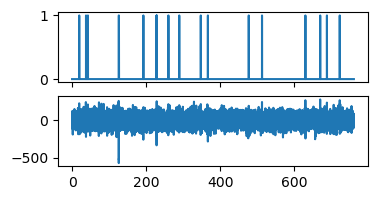

In [221]:
# identify noise artifacts using local changes in amplitude envelope
win_dur = 0.125 # seconds
norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)

# see how many trials have amplitude excursions within the ERP window
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds
n_samples = int(min_dur * resrate)
pre = -1
post = 2
plot_ts = np.linspace(pre,post,t_ixs.shape[1])

amp_mask = norm_env>MAD_thresh
ixA = np.min(np.where(plot_ts>=pre))
ixB = np.argmin(np.abs(plot_ts-post))
t_mask = np.sum(np.int64(amp_mask[t_ixs[:,ixA:ixB]]),axis=1)<n_samples
# filt_bip = np.ma.array(bipolar,mask=amp_mask)
# t_mask = filt_bip[t_ixs[:,ixA:ixB]].mask.sum(axis=1)<=1

print(pair)
print(f"Number of trials filtered: {sum(~t_mask)}")
print(f"Total percent of amplitude excursions: {round(100*(sum(norm_env>MAD_thresh))/len(norm_env),2)}%")
print(f"StDev of amplitude envelope: {round(np.std(norm_env),2)}")

fig,[ax1,ax2] = plt.subplots(2,1,figsize=(4,2))
ax1.plot(ts,amp_mask)
ax1.set_xticklabels([])
ax2.plot(ts,bipolar)
plt.show()

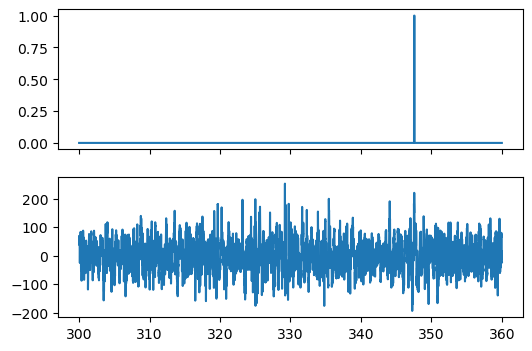

In [222]:
tfilt = (ts>300) & (ts<360)
fig,[ax1,ax2] = plt.subplots(2,1,figsize=(6,4))
ax1.plot(ts[tfilt],amp_mask[tfilt])
ax1.set_xticklabels([])
ax2.plot(ts[tfilt],bipolar[tfilt])
plt.show()



## Finding spikes

The line-length algorithm is useful for finding focal changes in signal amplitude, by simply taking the absolute difference in subsequent samples across a relatively short window. <br>

There's still the issue of calculating a threshold, however, which is particularly difficult when spikes are frequent - standard statistical methods start to fail in these cases because the amplitude distributions become so skewed. <br>

Instead, we can generate "neural-like" surrogate data segments that are based on FFT amplitude spectra, but scrambled phase spectra. Scrambling the phase and forcing an FFT-like reconstruction makes the likelihood that sharp, brief transients will be present in the surrogate data vanishingly small, but retaining the amplitude spectra retains the original signal's general amplitude distribution. <br>

Doing so means we can calculate max line-lengths of many surrogates to create a null distribution of "spike-free" line-length values for setting our threshold. <br>

We can then seek out the channel with the largest proportion of actual line-length amplitudes below the surrogate line-length distribution.

240.51561356499934 0.9999633669814393


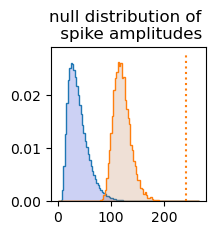

In [223]:
# number of samples to perform rolling calculation over
win = int(resrate/64)

# get null distribution from surrogate line-length maxima
null_dist = spike_utils.spike_surrogates(bipolar, t_ixs[t_mask,ixA:ixB], 10000, win)
spikeval = null_dist.max()

# actual data segments
spike_mat = filtering.rolling_sum(np.abs(np.diff(bipolar[t_ixs])),win,axis=-1)
# amp_dist = np.max(spike_mat,axis=1)
amp_dist = spike_mat.flatten()

print(spikeval, sum(amp_dist<spikeval)/len(amp_dist))
bins = np.linspace(0,1.1*max([null_dist.max(),np.percentile(spike_mat.flatten(),99.9)]),100)

fig,ax = plt.subplots(figsize=(2,2))
ax.hist(amp_dist,bins=bins, density=True,
        histtype="stepfilled",edgecolor="C0",facecolor=[0,0.1,0.8,0.2])
ax.hist(null_dist,bins=bins, density=True,
        histtype="stepfilled",edgecolor="C1",facecolor=[0.7,0.4,0.2,0.2])
ax.plot([spikeval,spikeval],ax.get_ylim(),":",color="C1")
ax.set_title("null distribution of \n spike amplitudes",horizontalalignment="center")
plt.show()

In [224]:
# use high line-lengths and surrogate derived threshold to find spikes
lls = filtering.rolling_sum(np.abs(np.diff(np.concat([(bipolar[1],),bipolar]))),win,axis=0)
ll_thresh = lls>spikeval
# "dilate" (expand) the mask b/c just a threshold crossing is not always adequate when spikes
# are relatively small and fast. This expands out by a number of samples
n_samps = 16; dilarray = np.ones([n_samps+1,],dtype=bool) # +1 to center ID'd events
from scipy.ndimage import binary_dilation
ll_mask = binary_dilation(ll_thresh,structure=dilarray)
# for fast spikes, the dilation can cause false positives
# make sure it doesn't add anything < spikeval/2
ll_mask[lls<(spikeval/2)] = False

# calculate the spike_prominences, filter nearby spikes
spike_ixs, spike_proms = spike_utils.find_spike_heights(bipolar,ll_mask,win,resrate,
                                                        prominence_wlen=int(resrate/4),
                                                        min_prominence=None,
                                                        suppress_ratio=1,
                                                        suppress_dist=32)

baseproms = find_peaks(bipolar[((~amp_mask)*(~ll_mask)).astype(bool)],prominence=(0))[1]["prominences"]
# standard deviations above the average "baseline" prominence (all "peaks" excluding amplitude excursions and ID'd spikes)
prom_thresh = np.mean(baseproms)+(2*np.nanstd(baseproms))
print(prom_thresh)
spike_ixs = spike_ixs[spike_proms>prom_thresh]

print(f"Number of spikes: {len(spike_ixs)}")
if len(spike_ixs) > 0:
    plt.hist(spike_proms, bins=np.linspace(0,spike_proms.max(),100))
    plt.plot([prom_thresh,prom_thresh],plt.ylim(),"r:")
    plt.show()
else:
    print("no spikes found")

110.29900621557394
Number of spikes: 0
no spikes found


## lots of visualization checks below

[24 61 87 79 74  1 84 28 46]


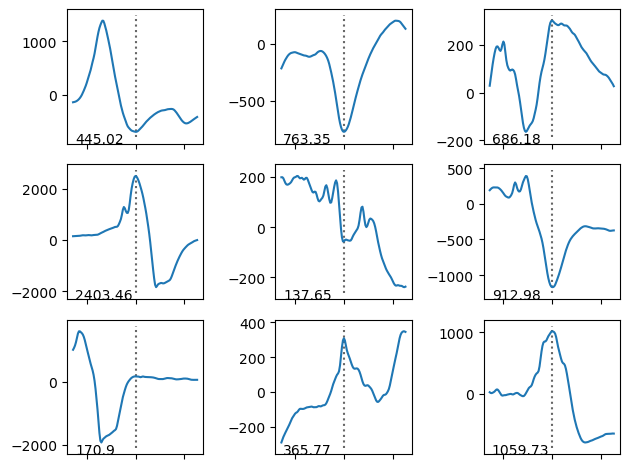

In [189]:
# need to do some searching through the indices to test for SNR or prominence or something
randspikes = rng.integers(low=0,high=len(spike_ixs),size=(9,))
print(randspikes)
fig,ax = plt.subplots(3,3,tight_layout=True)
ax = ax.flatten()
spk_win = win*4
p_spks = np.arange(-spk_win,spk_win)
for ii,spk in enumerate(randspikes):
    ax[ii].plot(p_spks,bipolar[(spike_ixs[spk]-spk_win):(spike_ixs[spk]+spk_win)])
    ax[ii].set_xticklabels([])
    ax[ii].plot([0,0],ax[ii].get_ylim(),linestyle=":",color=[0.4,0.4,0.4],zorder=0)
    ax[ii].text(-spk_win+2,min(ax[ii].get_ylim())+1,f"{np.round(spike_proms[spk],2)}")

plt.show()

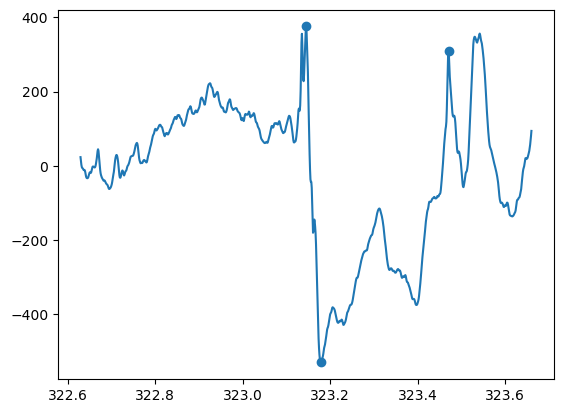

In [193]:
test_ix = rng.choice(spike_ixs)
p_ts = np.arange((test_ix-(win+int(resrate/2))),(test_ix+(win+int(resrate/2))))
plt.plot(ts[p_ts],bipolar[p_ts])
s_ts = p_ts[np.isin(p_ts,spike_ixs)]
plt.scatter(ts[s_ts],bipolar[s_ts])
plt.show()


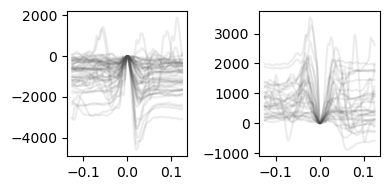

In [194]:
fig,[ax1,ax2] = plt.subplots(1,2, figsize=(4,2), tight_layout=True)
dt = 1/8
dsamps = int(resrate*dt)
xs = np.linspace(-dt,dt,2*dsamps)
for x in spike_ixs:
    if x<dsamps:
        continue
    if (bipolar[x]>bipolar[x-1]):
        ax1.plot(xs,bipolar[x-dsamps:x+dsamps]-bipolar[x], color=[0.3,0.3,0.3,0.1])
    if (bipolar[x]<bipolar[x-1]):
        ax2.plot(xs,bipolar[x-dsamps:x+dsamps]-bipolar[x], color=[0.3,0.3,0.3,0.1])
        

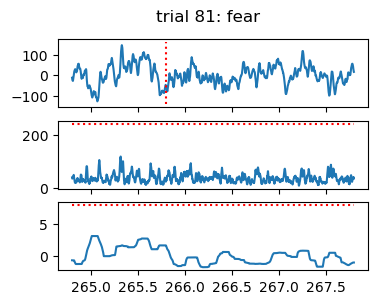

In [236]:
t = rng.integers(low=0, high=t_ixs.shape[0])
if t_mask[t]:
    c = "C0"
else:
    c = "r"
    
ixA = np.min(np.where(plot_ts>=pre))
ixB = np.argmin(np.abs(plot_ts-post))
p_ixs = t_ixs[t,ixA:ixB]
fig,[ax,ax1,ax2] = plt.subplots(3,1,sharex=True, figsize=(4,3))
ax.plot(ts[p_ixs],bipolar[p_ixs],color=c)
s_ts = spike_ixs[np.isin(spike_ixs,p_ixs)]
ax.scatter(ts[s_ts],bipolar[s_ts],color=c)
ax1.plot(ts[p_ixs],lls[p_ixs],color=c)
ax1.plot(ts[p_ixs[[0,-1]]],[spikeval,spikeval],"r:")
ax2.plot(ts[p_ixs],norm_env[p_ixs],color=c)
ax2.plot(ts[p_ixs[[0,-1]]],[MAD_thresh,MAD_thresh],"r:")
ax.plot(ts[p_ixs[[0,0]]]-pre,ax.get_ylim(),"r:")
# ax.set_xlim([683.2,683.3])
fig.suptitle(f"trial {t}: {events.img_category[t]}")
plt.show()


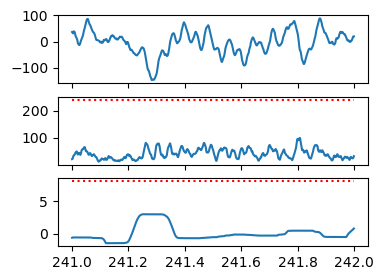

In [238]:
dt = 1
t0 = rng.integers(low=0, high=(ts.max()-dt))
# t0 = 481
p_ixs = np.arange(len(bipolar))[(ts>t0)&(ts<(t0+dt))]
fig,[ax,ax1,ax2] = plt.subplots(3,1,sharex=True, figsize=(4,3))
ax.plot(ts[p_ixs],bipolar[p_ixs])
s_ts = spike_ixs[np.isin(spike_ixs,p_ixs)]
ax.scatter(ts[s_ts],bipolar[s_ts])
ax1.plot(ts[p_ixs],lls[p_ixs],color="C0")
ax1.plot(ts[p_ixs[[0,-1]]],[spikeval,spikeval],"r:")
ax2.plot(ts[p_ixs],norm_env[p_ixs],color="C0")
ax2.plot(ts[p_ixs[[0,-1]]],[8,8],"r:")
# ax.set_xlim([683.2,683.3])
plt.show()


img_category
anger      45
fear       47
happy      47
house      47
neutral    48
Name: block, dtype: int64
9.176193574610775


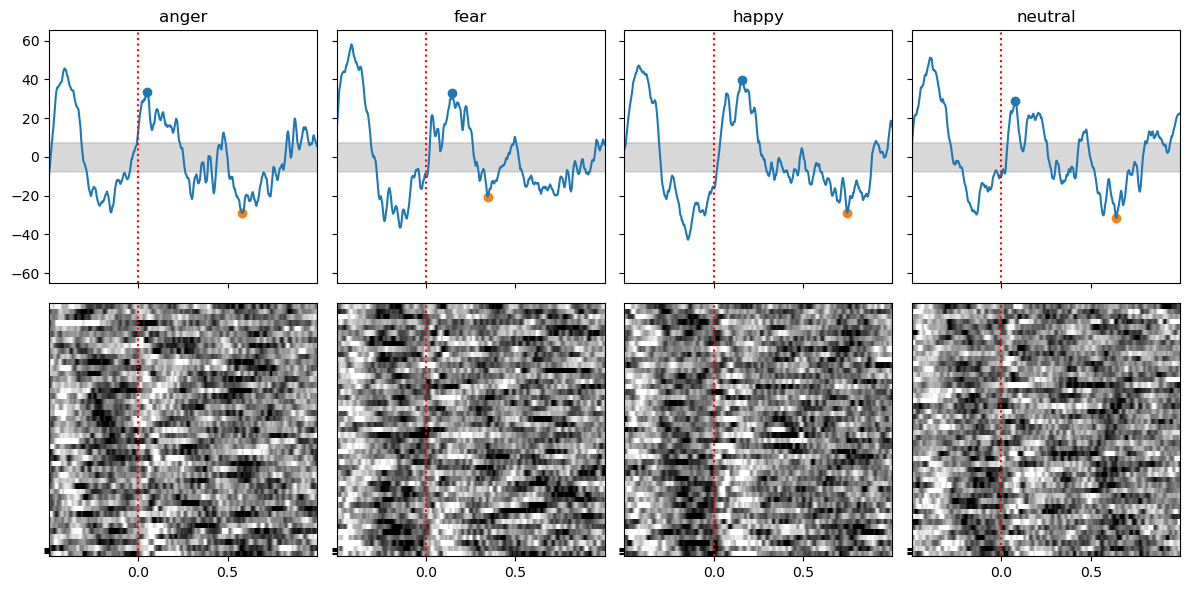

In [239]:
# hm, currently just masking high-amp trials (not spikes)
# continue only using spikes to arbitrate between channels
# but not filter from data?

ERP_tfilt = bipolar[t_ixs[t_mask,:]]
ERP_thresh = np.nanstd(np.nanmean(ERP_tfilt[:,(plot_ts<-0.5)],axis=0))*2.5
# reset ixA to be slightly after image start
ixA = np.argmin(np.abs(plot_ts-0.05))
ixB = np.argmin(np.abs(plot_ts-1))
ERP_amps,ERP_ax = plot_ERPs(ERP_tfilt, events.img_category[t_mask], ERP_thresh,
                            plot_ts, ixA, ixB)
img_cats = np.array(["anger","fear","neutral","happy","house"])

print(events.loc[t_mask,:].groupby(by="img_category").block.count())

print(max(abs(np.array([ERP_amps[cat] for cat in img_cats[img_cats!="house"]]))/ERP_thresh))
[ERP_ax[0,ix].set_xlim([-0.5,1.0]) for ix in range(len(ERP_ax))]
[ERP_ax[0,ix].set_xticks([-0,0.5], labels=["0.0","0.5"]) for ix in range(len(ERP_ax))]
plt.show()

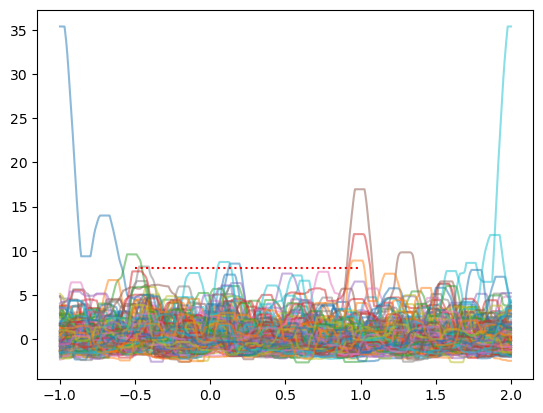

In [240]:
temp = norm_env[t_ixs[events.img_category!="house",:]]
filtwin = (plot_ts>-1)&(plot_ts<=2)
plt.plot(plot_ts[filtwin],temp[:,filtwin].T,alpha=0.5)
plt.plot([-0.5,1],[8,8],"r:")
# plt.ylim(-3,20)
plt.show()


## decide whether to keep contact pair
Based on the info from the plots/calculations above, decide whether to keep the current pair of channels <br>

**_Important_** <br>
By default, **ALL** data are set to be **DISCARDED** (until decisions to keep have been made). <br>
Thus, set `keep` to `True` below if you want to keep it!! <br>

### If you _do not_ want to keep the current pair of contacts, stop here


In [241]:
# decision about whether to keep pair (True or False)
# DO NOT Run cell below if you DO NOT want to keep
keep = True

## overwrite data with this cell

In [242]:
################################
### OVERWRITING MONTAGE FILE ###
################################
montage.loc[np.isin(montage.name,pair),"keep"] = keep
# can be more than one montage file
# just save the one that matches the EmotionTask data
# (well, should work as is for other data types, too)
mtype = fstr[-re.search(r'\\', fstr[::-1]).start():]
# figure out whether multiple files need to be overwritten
for fname in os.listdir(fstr):
    if re.search(r"montage\.csv$", fname, re.IGNORECASE) and (mtype in fname):
        path = os.path.join(fstr, fname)
        print(f"writing to {path}")
        montage.to_csv(path,index=False)
# check the parent folder as well        
for fname in os.listdir(os.path.dirname(fstr)): 
    if re.search(r"montage\.csv$", fname, re.IGNORECASE) and (mtype in fname):
        path = os.path.join(os.path.dirname(fstr), fname)
        print(f" writing to {path}")
        montage.to_csv(path,index=False)


 writing to C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\c5ec4c\EmotionTask_c5ec4c_montage.csv
